<a href="https://colab.research.google.com/github/pxtroniwnl/barcelona-de-indias-time-serie/blob/main/Data_Veget_Lago.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detección y seguimiento temporal de vegetación sobre una laguna usando Sentinel-2 y Sentinel-1

## Objetivo

Este proyecto tiene como objetivo detectar y cuantificar la vegetación presente sobre la superficie de una laguna a partir de imágenes satelitales, construyendo una serie temporal que permita analizar su comportamiento a lo largo del tiempo.

La metodología propuesta combina dos fuentes de información satelital:

- **Sentinel-2**, que se utiliza para delimitar la superficie de la laguna gracias a sus bandas ópticas, las cuales permiten diferenciar el agua de otros elementos del entorno.
- **Sentinel-1**, que se utiliza para monitorear en el tiempo la vegetación sobre el agua, aprovechando que el radar puede adquirir información incluso en presencia de nubes.

## Lógica general de trabajo

La estrategia metodológica sigue estos pasos:

1. Definir el área de estudio.
2. Construir una máscara fija del lago a partir de Sentinel-2.
3. Aplicar esa máscara a cada imagen de Sentinel-1.
4. Detectar dentro de la laguna la cobertura asociada a vegetación.
5. Calcular el área de vegetación en cada fecha.
6. Construir una serie temporal para analizar la evolución de la cobertura vegetal.

## Justificación

La combinación de Sentinel-2 y Sentinel-1 permite aprovechar las fortalezas de ambos sensores. Sentinel-2 ofrece mejor capacidad para identificar agua mediante índices espectrales, mientras que Sentinel-1 permite hacer seguimiento temporal continuo, incluso cuando las condiciones atmosféricas limitan el uso de imágenes ópticas.

---
#Autenticacion

In [ ]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

# Parametros generales del analisis
# Sentinel-1 tiene disponibilidad en esta zona desde 2017; por eso no se usa una fecha artificial anterior.
FECHA_INICIO_ANALISIS = '2017-01-01'
FECHA_FIN_ANALISIS = '2026-05-13'

# La mascara de agua se construye con imagenes Sentinel-2 recientes para obtener una referencia espacial fija.
# Esta decision permite comparar todas las fechas contra la misma superficie de laguna.
FECHA_INICIO_MASCARA = '2025-01-01'
FECHA_FIN_MASCARA = '2025-12-31'

UMBRAL_MNDWI_AGUA = 0.05
UMBRAL_VV_VEGETACION = -16
UMBRAL_VH_VEGETACION = -22
ESCALA_ANALISIS = 10

# Ejecutar Authenticate
ee.Authenticate(auth_mode='notebook')
ee.Initialize()


---
#Procesamiento

Definimos el ROI y la funcion de la mascara de las nubes

In [ ]:
"""
Módulo para el procesamiento de imágenes satelitales Sentinel-2.
Calcula el área y la máscara de agua de la Laguna de Barcelona de Indias
usando Google Earth Engine (EE).
"""

# --- DEFINICIÓN DE GEOMETRÍA ---
roi = ee.Geometry.Polygon([
    [
        [-75.476052, 10.517524], # Longitud, Latitud
        [-75.476117, 10.518747],
        [-75.473158, 10.519223],
        [-75.470516, 10.525108],
        [-75.469572, 10.524876],
        [-75.471686, 10.518916],
        [-75.468394, 10.517219],
        [-75.468952, 10.516459],
        [-75.476052, 10.517524]  # Cierre
    ]
])

# --- FUNCIONES DE PROCESAMIENTO ---

def mask_s2_clouds(image):
    """
    Aplica máscara de nubes y escala reflectancia para Sentinel-2.

    Args:
        image (ee.Image): Imagen S2 SR original.
    Returns:
        ee.Image: Imagen procesada.
    """
    image = ee.Image(image)
    qa = image.select('QA60')

    # Bits para nubes (10) y cirros (11)
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    mask = (qa.bitwiseAnd(cloud_bit_mask).eq(0)
            .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0)))

    return (image.updateMask(mask)
            .divide(10000)
            .copyProperties(image, ['system:time_start']))


def obtener_mascara_laguna(roi, fecha_inicio, fecha_fin):
    """
    Genera máscara binaria de agua basada en MNDWI y limpieza morfológica.

    Args:
        roi (ee.Geometry): Polígono del área de estudio.
        fecha_inicio (str): Inicio del rango temporal.
        fecha_fin (str): Fin del rango temporal.
    Returns:
        ee.Image: Máscara binaria (1: agua, 0: otros).
    """
    s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(roi)
          .filterDate(fecha_inicio, fecha_fin)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
          .map(mask_s2_clouds))

    composite = s2.median()

    # MNDWI = (Green - SWIR1) / (Green + SWIR1)
    mndwi = composite.normalizedDifference(['B3', 'B11']).rename('MNDWI')
    agua = mndwi.gt(UMBRAL_MNDWI_AGUA)

    # Limpieza morfológica: operación de cierre
    agua_limpia = (agua
                   .focal_max(radius=1, units='pixels')
                   .focal_min(radius=1, units='pixels')
                   .rename('agua'))

    return agua_limpia

# --- EJECUCIÓN Y CÁLCULO DE ÁREA ---

# Generar máscara fija de la laguna
mascara_fija = obtener_mascara_laguna(roi, FECHA_INICIO_MASCARA, FECHA_FIN_MASCARA)

# Reducción para obtener el área del espejo de agua
stats_area = mascara_fija.multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=roi,
    scale=ESCALA_ANALISIS,
    maxPixels=1e9
)

area_res = stats_area.get('agua')

if area_res is not None:
    area_total_laguna = ee.Number(area_res).getInfo()
    print(f"--- Análisis: Laguna de Barcelona de Indias ---")
    print(f"Área total estimada de la laguna: {area_total_laguna:.2f} m²")
else:
    print("Error: No se pudo calcular el área. Verifique el ROI o las fechas.")

--- Análisis: Laguna de Barcelona de Indias ---
Área total estimada de la laguna: 58897.36 m²


In [ ]:
Map = geemap.Map()
Map.centerObject(roi, 16)
Map.addLayer(mascara_fija.selfMask(), {'palette': ['blue']}, 'Máscara fija del lago')
Map.addLayer(roi, {'color': 'red'}, 'ROI', False)
Map

Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

## Seleccion de la coleccion Sentinel-1

Para el monitoreo temporal se utiliza Sentinel-1, un sensor radar que resulta especialmente util porque no depende de la iluminacion solar ni se ve tan afectado por la nubosidad.

La serie se construye desde `2017-01-01` hasta `2026-05-13`, que corresponde a la fecha actual de trabajo. No se usan fechas anteriores porque Sentinel-1 no tiene disponibilidad historica desde 1950; usar una fecha artificialmente antigua no aporta informaci?n y debilita la justificacion metodologica.

Se filtra la coleccion para trabajar unicamente con imagenes homogeneas, seleccionando:

- modo de adquisicion `IW`
- resolucion de 10 metros
- polarizaciones `VV` y `VH`
- una misma direccion orbital (`DESCENDING`)

Esto ayuda a reducir variaciones no deseadas entre imagenes y mejora la consistencia de la serie temporal.


In [ ]:
coleccion_radar = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate(FECHA_INICIO_ANALISIS, FECHA_FIN_ANALISIS)
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('resolution_meters', 10))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
    .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
    .select(['VV', 'VH', 'angle']))

print('Rango temporal Sentinel-1:', FECHA_INICIO_ANALISIS, 'a', FECHA_FIN_ANALISIS)
print('Numero de imagenes radar:', coleccion_radar.size().getInfo())


Rango temporal Sentinel-1: 2017-01-01 a 2026-05-13
Numero de imagenes radar: 301


###Detección de vegetación sobre el agua

Cada imagen de Sentinel-1 se recorta al área de estudio y se enmascara usando la máscara fija del lago. De esta forma, el análisis se realiza únicamente sobre la superficie de agua.

Luego se aplica una regla basada en los valores de retrodispersión de las bandas `VV` y `VH`. Esta regla busca diferenciar áreas con posible presencia de vegetación flotante o vegetación sobre el agua frente a zonas de agua libre.

Finalmente, para cada fecha se calcula:

- el área estimada de vegetación en metros cuadrados
- el área total del lago
- el porcentaje de cobertura vegetal

Estos resultados se almacenan como una colección de atributos por fecha.

In [ ]:
def procesar_fecha(image):
    # Recortar la imagen al ROI y dejar solo la zona del lago
    img_laguna = image.clip(roi).updateMask(mascara_fija)

    vv = img_laguna.select('VV')
    vh = img_laguna.select('VH')

    # Regla simple para detectar vegetacion sobre el agua.
    # Los umbrales deben interpretarse como criterio exploratorio y validarse visualmente.
    vegetacion = vv.gt(UMBRAL_VV_VEGETACION).And(vh.gt(UMBRAL_VH_VEGETACION)).rename('veg')

    # Calcular area de vegetacion
    area_veg = vegetacion.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=ESCALA_ANALISIS,
        maxPixels=1e9
    ).get('veg')

    # Calcular area total del lago con la misma mascara fija usada en toda la serie
    area_lago = mascara_fija.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=roi,
        scale=ESCALA_ANALISIS,
        maxPixels=1e9
    ).get('agua')

    area_veg = ee.Number(area_veg)
    area_lago = ee.Number(area_lago)

    porcentaje = area_veg.divide(area_lago).multiply(100)

    return ee.Feature(None, {
        'fecha': image.date().format('YYYY-MM-dd'),
        'id_imagen': image.get('system:index'),
        'orbita': image.get('orbitProperties_pass'),
        'area_m2_vegetacion': area_veg,
        'area_m2_lago': area_lago,
        'porcentaje_cobertura': porcentaje
    })


###Construcción de la tabla de resultados

La función anterior se aplica a todas las imágenes de Sentinel-1 dentro del período de estudio. Después, los resultados se convierten en un `DataFrame` de Pandas para facilitar su análisis, organización y visualización.

In [ ]:
fc_resultados = coleccion_radar.map(procesar_fecha)
resultados = fc_resultados.getInfo()['features']

df = pd.DataFrame([f['properties'] for f in resultados])
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)

df

,area_m2_lago,area_m2_vegetacion,fecha,id_imagen,orbita,porcentaje_cobertura
0,58897.358411,8421.864441,2017-05-26,S1B_IW_GRDH_1SDV_20170526T104833_20170526T1049...,DESCENDING,14.299223
1,58897.358411,6657.432907,2017-06-07,S1B_IW_GRDH_1SDV_20170607T104834_20170607T1049...,DESCENDING,11.303449
2,58897.358411,7090.690362,2017-06-19,S1B_IW_GRDH_1SDV_20170619T104834_20170619T1049...,DESCENDING,12.039063
3,58897.358411,7029.076869,2017-07-01,S1B_IW_GRDH_1SDV_20170701T104835_20170701T1049...,DESCENDING,11.934452
4,58897.358411,6571.486052,2017-07-13,S1B_IW_GRDH_1SDV_20170713T104836_20170713T1049...,DESCENDING,11.157523
...,...,...,...,...,...,...
296,58897.358411,5754.417982,2026-04-22,S1D_IW_GRDH_1SDV_20260422T104848_20260422T1049...,DESCENDING,9.770248
297,58897.358411,4252.532201,2026-04-27,S1A_IW_GRDH_1SDV_20260427T104936_20260427T1050...,DESCENDING,7.220243
298,58897.358411,6268.913103,2026-05-03,S1C_IW_GRDH_1SDV_20260503T104839_20260503T1049...,DESCENDING,10.643793
299,58897.358411,4595.921341,2026-05-04,S1D_IW_GRDH_1SDV_20260504T104849_20260504T1049...,DESCENDING,7.803272


###Preparación de la serie temporal

Se organiza una tabla final con las variables más importantes del análisis temporal:

- fecha de adquisición
- área de vegetación detectada
- porcentaje de cobertura
- identificador de la imagen
- tipo de órbita

Esta tabla constituye la base de la serie temporal del proyecto.

In [ ]:
df_ts = df[['fecha', 'area_m2_vegetacion', 'porcentaje_cobertura', 'id_imagen', 'orbita']].copy()
df_ts.head()

,fecha,area_m2_vegetacion,porcentaje_cobertura,id_imagen,orbita
0,2017-05-26,8421.864441,14.299223,S1B_IW_GRDH_1SDV_20170526T104833_20170526T1049...,DESCENDING
1,2017-06-07,6657.432907,11.303449,S1B_IW_GRDH_1SDV_20170607T104834_20170607T1049...,DESCENDING
2,2017-06-19,7090.690362,12.039063,S1B_IW_GRDH_1SDV_20170619T104834_20170619T1049...,DESCENDING
3,2017-07-01,7029.076869,11.934452,S1B_IW_GRDH_1SDV_20170701T104835_20170701T1049...,DESCENDING
4,2017-07-13,6571.486052,11.157523,S1B_IW_GRDH_1SDV_20170713T104836_20170713T1049...,DESCENDING


## Validacion visual de fechas representativas

La serie temporal entrega una estimacion cuantitativa por fecha, pero es necesario revisar mapas para verificar si las areas detectadas son espacialmente coherentes. Para evitar seleccionar fechas de manera subjetiva, se eligen cinco casos representativos a partir de la distribucion del area detectada: minimo, cuartil bajo, mediana, cuartil alto y maximo.

Estas fechas no sustituyen una validacion en campo, pero ayudan a comprobar visualmente si el criterio radar esta identificando zonas plausibles dentro de la superficie de la laguna.


In [ ]:
# Seleccionar automaticamente cinco fechas representativas de la serie temporal
# Se usa una imagen por fecha; si hay mas de una imagen el mismo dia, se conserva la de mayor area detectada.
df['fecha'] = pd.to_datetime(df['fecha'])

df_unico = (df.sort_values(['fecha', 'area_m2_vegetacion'], ascending=[True, False])
              .drop_duplicates(subset='fecha')
              .sort_values('area_m2_vegetacion')
              .reset_index(drop=True))

posiciones = [0, 0.25, 0.50, 0.75, 1]
indices = sorted(set(round(p * (len(df_unico) - 1)) for p in posiciones))

fechas_ejemplo = (df_unico.iloc[indices]
                  .sort_values('fecha')
                  .reset_index(drop=True))

print('Fechas representativas seleccionadas:')
display(fechas_ejemplo[['fecha', 'area_m2_vegetacion', 'porcentaje_cobertura', 'id_imagen']])


Fechas representativas seleccionadas:


,fecha,area_m2_vegetacion,porcentaje_cobertura,id_imagen
0,2019-04-10,562.373642,0.954837,S1B_IW_GRDH_1SDV_20190410T104844_20190410T1049...
1,2021-09-14,2855.821790,4.848811,S1B_IW_GRDH_1SDV_20210914T104904_20210914T1049...
2,2022-03-19,1951.235262,3.312942,S1A_IW_GRDH_1SDV_20220319T104943_20220319T1050...
3,2023-06-18,3952.704431,6.711174,S1A_IW_GRDH_1SDV_20230618T104952_20230618T1050...
4,2025-10-11,12874.152405,21.858624,S1C_IW_GRDH_1SDV_20251011T104841_20251011T1049...


### Funcion de visualizacion por imagen

Para que la visualizacion sea reproducible, cada mapa se genera usando el `id_imagen` guardado en la tabla de resultados. Asi se evita que Earth Engine seleccione una imagen cercana pero distinta a la usada en el calculo de area.


In [ ]:
def obtener_imagen_por_id(id_imagen):
    imagen = coleccion_radar.filter(ee.Filter.eq('system:index', id_imagen)).first()
    return ee.Image(imagen)


In [ ]:
def mostrar_imagen_por_id(id_imagen, fecha_str, umbral_vv=UMBRAL_VV_VEGETACION, umbral_vh=UMBRAL_VH_VEGETACION):
    imagen = obtener_imagen_por_id(id_imagen)
    imagen_solo_laguna = imagen.clip(roi).updateMask(mascara_fija)

    vv = imagen_solo_laguna.select('VV')
    vh = imagen_solo_laguna.select('VH')

    capa_vegetacion = vv.gt(umbral_vv).And(vh.gt(umbral_vh))

    Map = geemap.Map()
    Map.centerObject(roi, 16)

    Map.addLayer(mascara_fija.selfMask(), {'palette': ['#0000AA']}, 'Mascara de laguna')
    Map.addLayer(vv, {'min': -25, 'max': 0}, f'Sentinel-1 VV {fecha_str}', False)
    Map.addLayer(vh, {'min': -30, 'max': -5}, f'Sentinel-1 VH {fecha_str}', False)
    Map.addLayer(capa_vegetacion.selfMask(), {'palette': ['#00FF00']}, f'Vegetaci?n detectada ({fecha_str})')
    Map.addLayer(roi, {'color': 'red'}, 'ROI', False)

    return Map


In [ ]:
for i, row in fechas_ejemplo.iterrows():
    fecha_str = row['fecha'].strftime('%Y-%m-%d')
    area_veg = row['area_m2_vegetacion']
    cobertura = row['porcentaje_cobertura']
    id_imagen = row['id_imagen']

    print(f"Imagen {i+1} - Fecha: {fecha_str} | area: {area_veg:.2f} m? | Cobertura: {cobertura:.2f}%")
    display(mostrar_imagen_por_id(id_imagen, fecha_str))


Imagen 1 - Fecha: 2019-04-10 | area: 562.37 m? | Cobertura: 0.95%


Map(center=[10.519386983714051, -75.47203874749312], controls=(WidgetControl(options=['position', 'transparent…

Imagen 2 - Fecha: 2021-09-14 | area: 2855.82 m? | Cobertura: 4.85%


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

Imagen 3 - Fecha: 2022-03-19 | area: 1951.24 m? | Cobertura: 3.31%


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

Imagen 4 - Fecha: 2023-06-18 | area: 3952.70 m? | Cobertura: 6.71%


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

Imagen 5 - Fecha: 2025-10-11 | area: 12874.15 m? | Cobertura: 21.86%


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

## Analisis de sensibilidad de umbrales

El criterio principal usa `VV > -16 dB` y `VH > -22 dB`. Como estos umbrales son exploratorios, se incluye una prueba visual de sensibilidad para revisar como cambia la deteccion al variar el umbral de `VV`, manteniendo fijo el umbral de `VH`.

Esta seccion no redefine los resultados principales; solo ayuda a justificar si el umbral elegido produce una delimitacion razonable.


In [ ]:
def comparar_umbrales_por_id(id_imagen, fecha_str, umbrales_vv=[-17, -16, -15, -14], umbral_vh=UMBRAL_VH_VEGETACION):
    imagen = obtener_imagen_por_id(id_imagen)
    imagen_solo_laguna = imagen.clip(roi).updateMask(mascara_fija)

    vv = imagen_solo_laguna.select('VV')
    vh = imagen_solo_laguna.select('VH')

    for umbral_vv in umbrales_vv:
        capa_vegetacion = vv.gt(umbral_vv).And(vh.gt(umbral_vh))

        print(f"Fecha: {fecha_str} | Umbral VV > {umbral_vv} y VH > {umbral_vh}")
        Map = geemap.Map()
        Map.centerObject(roi, 16)

        Map.addLayer(mascara_fija.selfMask(), {'palette': ['#0000AA']}, 'M?scara de laguna')
        Map.addLayer(vv, {'min': -25, 'max': 0}, f'VV {fecha_str}', False)
        Map.addLayer(vh, {'min': -30, 'max': -5}, f'VH {fecha_str}', False)
        Map.addLayer(capa_vegetacion.selfMask(), {'palette': ['#00FF00']}, f'Vegetaci?n VV>{umbral_vv}, VH>{umbral_vh}')
        Map.addLayer(roi, {'color': 'red'}, 'ROI', False)
        display(Map)


In [ ]:
# Probar distintos umbrales con la fecha de mayor area detectada
fecha_prueba = df_unico.loc[df_unico['area_m2_vegetacion'].idxmax()]
fecha_prueba_str = fecha_prueba['fecha'].strftime('%Y-%m-%d')
comparar_umbrales_por_id(
    fecha_prueba['id_imagen'],
    fecha_prueba_str,
    umbrales_vv=[-17, -16, -15, -14]
)


Fecha: 2025-10-11 | Umbral VV > -17 y VH > -22


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

Fecha: 2025-10-11 | Umbral VV > -16 y VH > -22


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

Fecha: 2025-10-11 | Umbral VV > -15 y VH > -22


Map(center=[10.519386983714051, -75.47203874749312], controls=(WidgetControl(options=['position', 'transparent…

Fecha: 2025-10-11 | Umbral VV > -14 y VH > -22


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

## Visualizacion de la serie temporal

Finalmente se grafican el area detectada y el porcentaje de cobertura vegetal estimada. Las fechas representativas seleccionadas se resaltan sobre la serie para conectar los resultados cuantitativos con la revision visual de mapas.


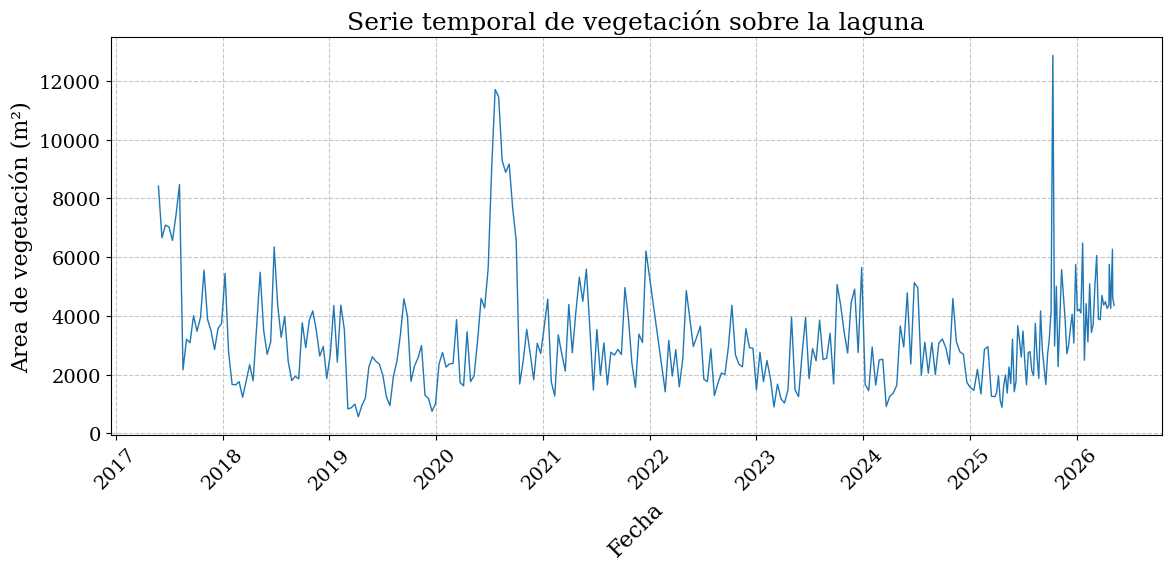

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_ts['fecha'], df_ts['area_m2_vegetacion'], linewidth=1)
plt.title('Serie temporal de vegetación sobre la laguna')
plt.xlabel('Fecha')
plt.ylabel('Area de vegetación (m²)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.yticks(r)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


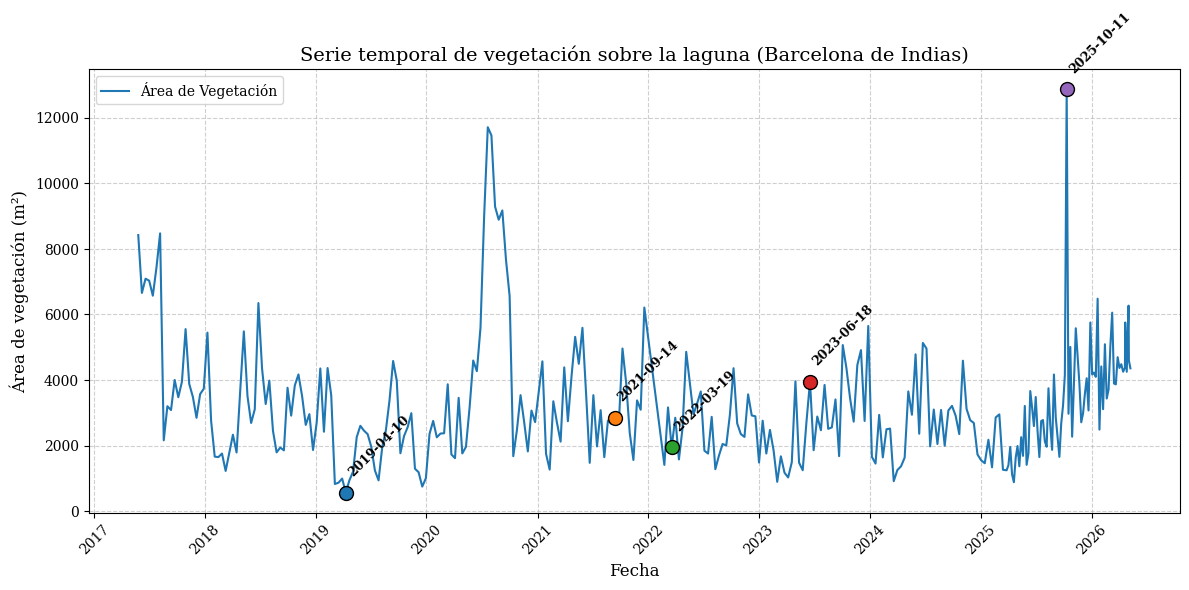

¡Gráficos guardados! Busca en la carpeta de archivos de tu notebook los archivos .png y .pdf


In [ ]:
import matplotlib.pyplot as plt

# 1. Configurar el estilo para publicación (opcional pero recomendado)
plt.rcParams.update({'font.size': 10, 'font.family': 'serif'})

plt.figure(figsize=(12, 6))
plt.plot(df_ts['fecha'], df_ts['area_m2_vegetacion'], linewidth=1.5, color='#1f77b4', label='Área de Vegetación')
plt.title('Serie temporal de vegetación sobre la laguna (Barcelona de Indias)', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Área de vegetación (m²)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Resaltar puntos de ejemplo
for _, row in fechas_ejemplo.iterrows():
    plt.scatter(row['fecha'], row['area_m2_vegetacion'], s=100, edgecolor='black', zorder=5)
    plt.text(
        row['fecha'],
        row['area_m2_vegetacion'] + 500,
        row['fecha'].strftime('%Y-%m-%d'),
        fontsize=9,
        rotation=45,
        fontweight='bold'
    )

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# --- CLAVE PARA LA DESCARGA PROFESIONAL ---

# Opción A: PNG de alta resolución (300 DPI)
plt.savefig('serie_temporal_vegetacion_300dpi.png', dpi=300, bbox_inches='tight')

# Opción B: PDF (Formato Vectorial - Recomendado para Papers de alta calidad)
# El PDF no pierde resolución sin importar cuánto zoom se haga en Overleaf/LaTeX
plt.savefig('serie_temporal_vegetacion.pdf', bbox_inches='tight')

plt.show()

print("¡Gráficos guardados! Busca en la carpeta de archivos de tu notebook los archivos .png y .pdf")

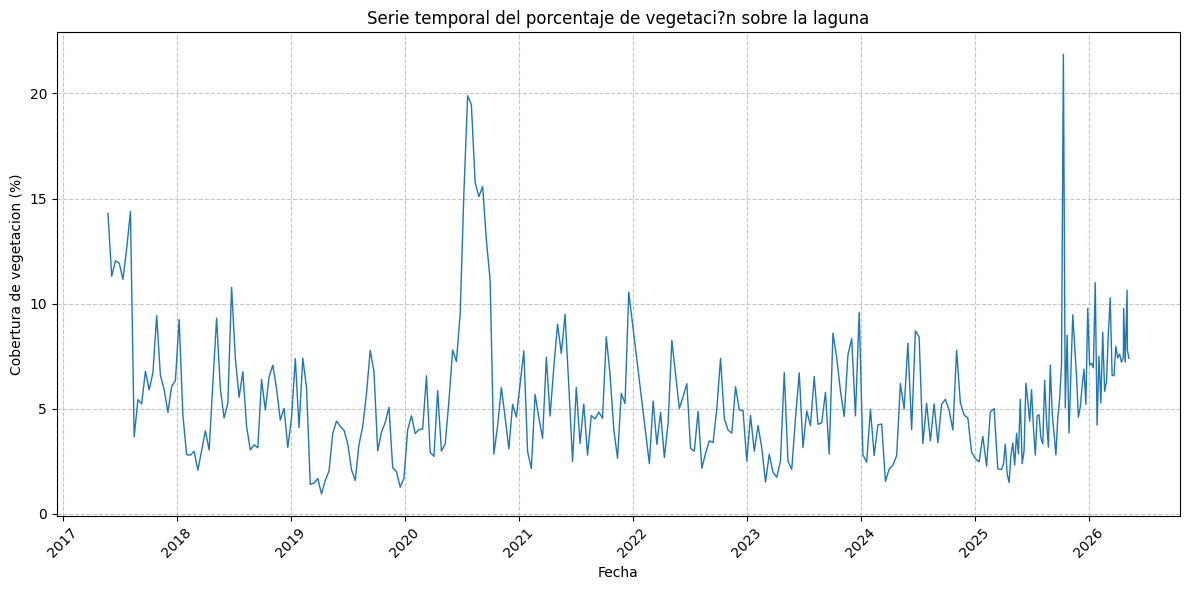

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_ts['fecha'], df_ts['porcentaje_cobertura'], linewidth=1)
plt.title('Serie temporal del porcentaje de vegetaci?n sobre la laguna')
plt.xlabel('Fecha')
plt.ylabel('Cobertura de vegetacion (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


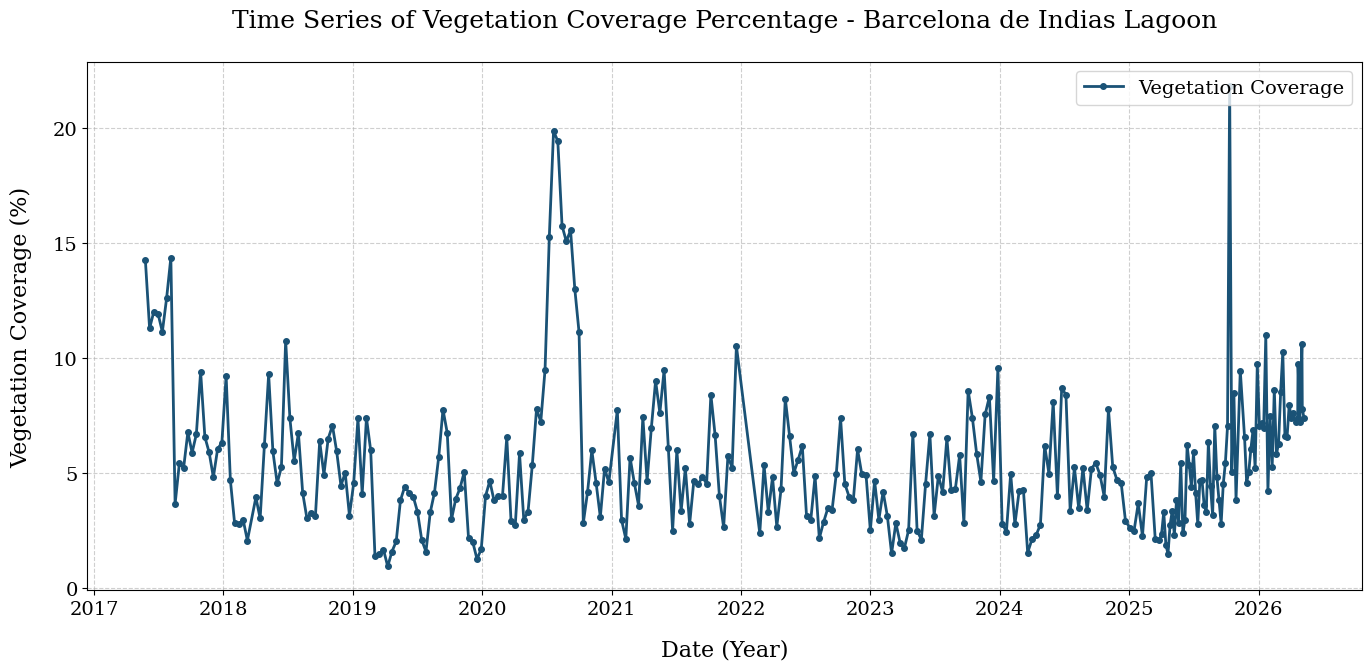

Files downloaded to your session: 'vegetation_coverage_timeseries.pdf' and '.png'


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- CONFIGURACIÓN DE ESTILO PROFESIONAL ---
FONT_SIZE_TITLE = 18
FONT_SIZE_LABELS = 16
FONT_SIZE_TICKS = 14
FONT_SIZE_LEGEND = 14

plt.rcParams.update({
    'font.size': FONT_SIZE_LABELS,
    'font.family': 'serif',
    'axes.titlesize': FONT_SIZE_TITLE,
    'axes.labelsize': FONT_SIZE_LABELS,
    'xtick.labelsize': FONT_SIZE_TICKS,
    'ytick.labelsize': FONT_SIZE_TICKS,
    'legend.fontsize': FONT_SIZE_LEGEND
})

plt.figure(figsize=(14, 7))

# Graficar la serie
plt.plot(
    df_ts['fecha'],
    df_ts['porcentaje_cobertura'],
    linewidth=2,
    color='#1a5276',
    marker='o',
    markersize=4,
    label='Vegetation Coverage'
)

# Títulos y Etiquetas en Inglés
plt.title('Time Series of Vegetation Coverage Percentage - Barcelona de Indias Lagoon', pad=25)
plt.xlabel('Date (Year)', labelpad=15)
plt.ylabel('Vegetation Coverage (%)', labelpad=15)

# --- AJUSTE DE EJES ---
# Forzar a que los años se vean en horizontal (rotation=0)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=0)

# Cuadrícula y leyenda
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', frameon=True)

# Ajuste de diseño
plt.tight_layout()

# --- EXPORTACIÓN PARA PAPER (300 DPI) ---
# El PDF es el formato estándar para Overleaf/LaTeX (vectorial)
plt.savefig('vegetation_coverage_timeseries.pdf', bbox_inches='tight')
# PNG de alta resolución como respaldo
plt.savefig('vegetation_coverage_timeseries_300dpi.png', dpi=300, bbox_inches='tight')

plt.show()

print("Files downloaded to your session: 'vegetation_coverage_timeseries.pdf' and '.png'")

## Incorporacion de indices opticos Sentinel-2: NDAVI y FAI

Ademas de la serie principal con Sentinel-1, se incorporan indices opticos de Sentinel-2 para revisar si las zonas detectadas por radar coinciden con señales espectrales asociadas a vegetacion acuatica o material flotante.

En este notebook los indices opticos se usan primero como **validacion visual y comparacion metodologica**, no como reemplazo directo de la serie radar. La razon es que Sentinel-2 depende de condiciones despejadas; por tanto, una serie optica completa tendria huecos por nubes y sombras.

- **NDAVI** compara el infrarrojo cercano (`B8`) con el azul (`B2`). Puede resaltar vegetacion acuatica o flotante porque la vegetacion suele reflejar mas en NIR que el agua libre.
- **FAI** estima el exceso de reflectancia en NIR respecto a una linea base entre rojo (`B4`) y SWIR (`B11`). Es util para material flotante, algas o vegetacion en superficie.

Las limitaciones principales son la nubosidad, sombras, mezcla de pixeles en bordes y el hecho de que `B11` tiene resolucion nativa de 20 m, mientras que `B2`, `B4` y `B8` son de 10 m.


In [ ]:
def agregar_indices_opticos(image):
    blue = image.select('B2')
    red = image.select('B4')
    nir = image.select('B8')
    swir = image.select('B11')

    # NDAVI = (NIR - Blue) / (NIR + Blue)
    ndavi = nir.subtract(blue).divide(nir.add(blue)).rename('NDAVI')

    # FAI = NIR - [Red + (SWIR - Red) * ((lambda_NIR - lambda_Red) / (lambda_SWIR - lambda_Red))]
    lambda_red = 665
    lambda_nir = 842
    lambda_swir = 1610
    factor = (lambda_nir - lambda_red) / (lambda_swir - lambda_red)

    fai_base = red.add(swir.subtract(red).multiply(factor))
    fai = nir.subtract(fai_base).rename('FAI')

    return image.addBands([ndavi, fai])


In [ ]:
def mask_s2_clouds_optica(image):
    image = ee.Image(image)
    qa = image.select('QA60')

    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
        qa.bitwiseAnd(cirrus_bit_mask).eq(0)
    )

    return (image.updateMask(mask)
            .divide(10000)
            .copyProperties(image, [
                'system:time_start',
                'system:index',
                'CLOUDY_PIXEL_PERCENTAGE'
            ]))


coleccion_s2_optica = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(roi)
    .filterDate(FECHA_INICIO_ANALISIS, FECHA_FIN_ANALISIS)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80))
    .map(mask_s2_clouds_optica)
    .map(agregar_indices_opticos))

print('Numero de imagenes Sentinel-2 opticas disponibles:', coleccion_s2_optica.size().getInfo())


Numero de imagenes Sentinel-2 opticas disponibles: 393


### Visualizacion optica en fechas representativas

Para comparar Sentinel-1 con Sentinel-2 se buscan imagenes opticas cercanas a las fechas representativas de la serie radar. La comparacion debe interpretarse con cuidado: si la imagen Sentinel-2 mas cercana tiene nubes, sombras o varios dias de diferencia, no necesariamente representara exactamente la misma condicion observada por Sentinel-1.


In [ ]:
def obtener_s2_cercana(fecha_str, ventanas_dias=[10, 30, 60], max_nubosidad=80):
    fecha = ee.Date(fecha_str)

    for ventana in ventanas_dias:
        candidatos = (coleccion_s2_optica
                      .filterDate(fecha.advance(-ventana, 'day'), fecha.advance(ventana + 1, 'day'))
                      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', max_nubosidad))
                      .sort('CLOUDY_PIXEL_PERCENTAGE'))

        n = candidatos.size().getInfo()
        if n > 0:
            imagen = ee.Image(candidatos.first())
            return {
                'imagen': imagen,
                'fecha_s2': imagen.date().format('YYYY-MM-dd').getInfo(),
                'nubosidad_s2': imagen.get('CLOUDY_PIXEL_PERCENTAGE').getInfo(),
                'ventana_dias': ventana,
                'n_candidatas': n
            }

    return {
        'imagen': None,
        'fecha_s2': None,
        'nubosidad_s2': None,
        'ventana_dias': None,
        'n_candidatas': 0
    }



In [ ]:
def mostrar_indices_opticos(fecha_str, ventanas_dias=[10, 30, 60], max_nubosidad=80):
    resultado = obtener_s2_cercana(fecha_str, ventanas_dias, max_nubosidad)
    imagen = resultado['imagen']

    if imagen is None:
        print(f'No se encontro imagen Sentinel-2 para {fecha_str} usando ventanas {ventanas_dias}.')
        return None

    fecha_s2 = resultado['fecha_s2']
    nubosidad = resultado['nubosidad_s2']
    ventana = resultado['ventana_dias']

    imagen_s2 = imagen.clip(roi).updateMask(mascara_fija)
    print(f'Sentinel-2 usado: {fecha_s2} | nubosidad escena: {nubosidad:.2f}% | ventana: +/-{ventana} dias')

    Map = geemap.Map()
    Map.centerObject(roi, 16)

    Map.addLayer(imagen_s2.select(['B4', 'B3', 'B2']),
                 {'min': 0.02, 'max': 0.25},
                 f'Sentinel-2 RGB {fecha_s2}', False)

    Map.addLayer(imagen_s2.select(['B8', 'B4', 'B3']),
                 {'min': 0.02, 'max': 0.35},
                 f'Sentinel-2 falso color {fecha_s2}', False)

    Map.addLayer(imagen_s2.select('NDAVI'),
                 {'min': -0.5, 'max': 0.8, 'palette': ['#08306b', '#deebf7', '#ffffbf', '#31a354']},
                 'NDAVI')

    Map.addLayer(imagen_s2.select('FAI'),
                 {'min': -0.02, 'max': 0.08, 'palette': ['#08306b', '#f7f7f7', '#fee08b', '#d73027']},
                 'FAI')

    Map.addLayer(mascara_fija.selfMask(), {'palette': ['#0000AA']}, 'Mascara de laguna', False)
    Map.addLayer(roi, {'color': 'red'}, 'ROI', False)

    return Map

In [ ]:
# Mostrar NDAVI y FAI para las mismas fechas representativas usadas en la validacion radar
for i, row in fechas_ejemplo.iterrows():
    fecha_str = row['fecha'].strftime('%Y-%m-%d')
    print(f'Indices opticos para fecha radar representativa {i+1}: {fecha_str}')
    mapa_optico = mostrar_indices_opticos(fecha_str, ventanas_dias=[10, 30, 60], max_nubosidad=80)
    if mapa_optico is not None:
        display(mapa_optico)


Indices opticos para fecha radar representativa 1: 2019-04-10
Sentinel-2 usado: 2019-04-07 | nubosidad escena: 2.50% | ventana: +/-10 dias


Map(center=[10.519386983714051, -75.47203874749312], controls=(WidgetControl(options=['position', 'transparent…

Indices opticos para fecha radar representativa 2: 2021-09-14
Sentinel-2 usado: 2021-09-18 | nubosidad escena: 26.01% | ventana: +/-10 dias


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

Indices opticos para fecha radar representativa 3: 2022-03-19
Sentinel-2 usado: 2022-03-22 | nubosidad escena: 2.34% | ventana: +/-10 dias


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

Indices opticos para fecha radar representativa 4: 2023-06-18
Sentinel-2 usado: 2023-06-20 | nubosidad escena: 0.52% | ventana: +/-10 dias


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

Indices opticos para fecha radar representativa 5: 2025-10-11
Sentinel-2 usado: 2025-10-17 | nubosidad escena: 50.36% | ventana: +/-10 dias


Map(center=[10.519386983662919, -75.47203874744568], controls=(WidgetControl(options=['position', 'transparent…

## Comparacion cuantitativa preliminar Sentinel-1 vs Sentinel-2

Como primer acercamiento, se calcula el promedio de NDAVI y FAI dentro de la mascara fija de la laguna para las fechas representativas. Esta comparacion no entrega todavia un area optica de vegetacion, pero permite revisar si las fechas con mayor cobertura radar tambien presentan valores opticos mas altos.

Una etapa posterior podria definir umbrales opticos para NDAVI o FAI y construir una segunda serie temporal optica. Sin embargo, conviene hacerlo despues de revisar visualmente varias fechas despejadas, para no introducir un umbral arbitrario.


In [125]:
def calcular_resumen_optico(fecha_str, ventanas_dias=[10, 30, 60], max_nubosidad=80):
    resultado = obtener_s2_cercana(fecha_str, ventanas_dias, max_nubosidad)
    imagen = resultado['imagen']

    if imagen is None:
        return {
            'fecha_radar': fecha_str,
            'fecha_s2': None,
            'nubosidad_s2': None,
            'ventana_dias': None,
            'NDAVI_promedio': None,
            'FAI_promedio': None
        }

    imagen_s2 = imagen.clip(roi).updateMask(mascara_fija)

    resumen = imagen_s2.select(['NDAVI', 'FAI']).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=ESCALA_ANALISIS,
        maxPixels=1e9
    ).getInfo()

    return {
        'fecha_radar': fecha_str,
        'fecha_s2': resultado['fecha_s2'],
        'nubosidad_s2': resultado['nubosidad_s2'],
        'ventana_dias': resultado['ventana_dias'],
        'NDAVI_promedio': resumen.get('NDAVI'),
        'FAI_promedio': resumen.get('FAI')
    }

In [126]:
resultados_opticos = []
for _, row in fechas_ejemplo.iterrows():
    fecha_str = row['fecha'].strftime('%Y-%m-%d')
    resultados_opticos.append(calcular_resumen_optico(fecha_str, ventanas_dias=[10, 30, 60], max_nubosidad=80))

df_opticos = pd.DataFrame(resultados_opticos)
df_comparacion = fechas_ejemplo[['fecha', 'area_m2_vegetacion', 'porcentaje_cobertura']].copy()
df_comparacion['fecha_radar'] = df_comparacion['fecha'].dt.strftime('%Y-%m-%d')
df_comparacion = df_comparacion.merge(df_opticos, on='fecha_radar', how='left')

df_comparacion[['fecha_radar', 'fecha_s2', 'nubosidad_s2', 'ventana_dias', 'area_m2_vegetacion', 'porcentaje_cobertura', 'NDAVI_promedio', 'FAI_promedio']]

,fecha_radar,fecha_s2,nubosidad_s2,ventana_dias,area_m2_vegetacion,porcentaje_cobertura,NDAVI_promedio,FAI_promedio
0,2019-04-10,2019-04-07,2.498184,10,562.373642,0.954837,-0.026612,-0.019623
1,2021-09-14,2021-09-18,26.007038,10,2855.821790,4.848811,0.082442,0.035442
2,2022-03-19,2022-03-22,2.342477,10,1951.235262,3.312942,0.053847,0.014240
3,2023-06-18,2023-06-20,0.516899,10,3952.704431,6.711174,0.184801,0.009817
4,2025-10-11,2025-10-17,50.356746,10,12874.152405,21.858624,NaN,NaN


## Conclusiones metodologicas parciales

El flujo recomendado queda dividido en dos niveles. Sentinel-1 se mantiene como la serie temporal principal porque permite monitorear muchas fechas incluso con nubosidad. Sentinel-2 cumple dos funciones complementarias: primero, delimitar la laguna mediante MNDWI; segundo, aportar evidencia optica con NDAVI y FAI para revisar si las detecciones radar son consistentes con señales de vegetacion acuatica o material flotante.

La interpretacion debe mantenerse prudente: el metodo identifica **posible vegetaci?n sobre la superficie de la laguna**, no una clasificacion validada en campo. Los resultados dependen de la calidad de la mascara de agua, los umbrales radar, la geometria de adquisicion, la nubosidad en Sentinel-2 y la mezcla espectral en un cuerpo de agua pequeño.
